> **Solucion.** Notebook original del curso con los `TODO` completados y verificados: todos los `assert` de las celdas de prueba pasan y el notebook corre de principio a fin (`Restart & Run All`). Enunciados, visualizaciones y pruebas quedan intactos.
>
> Nicolas Rodriguez

# Taller de código 2: optimización local

Resolverás el problema de las **8 reinas** con Hill Climbing y Simulated Annealing.

Un estado es una lista donde el índice representa la columna y el valor representa la fila de cada reina. El costo es el número de pares de reinas que se atacan. Buscamos minimizarlo hasta llegar a cero.

Tiempo estimado: **60–75 minutos**.

In [1]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
N = 8

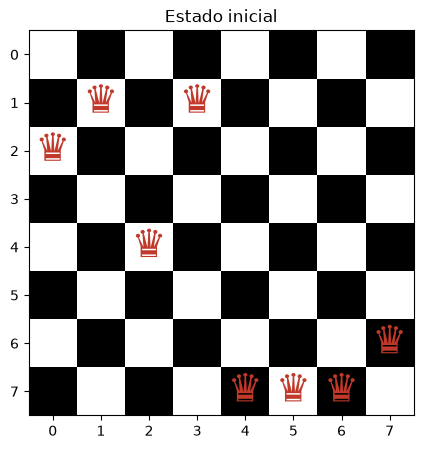

In [2]:
def plot_board(state, title=None):
    n = len(state)
    board = np.fromfunction(lambda row, col: (row + col) % 2, (n, n))
    plt.figure(figsize=(5, 5))
    plt.imshow(board, cmap="Greys", vmin=0, vmax=1)
    for col, row in enumerate(state):
        plt.text(col, row, "♛", ha="center", va="center", fontsize=28, color="#c0392b")
    plt.xticks(range(n)); plt.yticks(range(n))
    plt.title(title or str(state))
    plt.show()

initial_state = [2, 1, 4, 1, 7, 7, 7, 6]
plot_board(initial_state, "Estado inicial")

## Actividad 1 — Función de costo

Cuenta cuántos pares de reinas comparten fila o diagonal. Cada pareja debe contarse una sola vez.

In [3]:
def conflicts(state):
    """Numero de pares de reinas que se atacan (misma fila o misma diagonal)."""
    n = len(state)
    total = 0
    for i in range(n):
        for j in range(i + 1, n):                  # solo columnas posteriores
            if state[i] == state[j] or abs(state[i] - state[j]) == abs(i - j):
                total += 1
    return total

In [4]:
assert conflicts([0, 1, 2, 3]) == 6
assert conflicts([1, 3, 0, 2]) == 0
assert conflicts([0, 0, 2, 3]) > 0
print("Pruebas de costo superadas.")

Pruebas de costo superadas.


## Actividad 2 — Generación de vecinos

Un vecino se obtiene moviendo una reina a otra fila dentro de su misma columna.

In [5]:
def get_neighbors(state):
    """Todos los estados a un movimiento: mover exactamente una reina de fila."""
    neighbors = []
    for col in range(len(state)):
        for row in range(len(state)):
            if row != state[col]:
                nb = list(state)
                nb[col] = row
                neighbors.append(nb)
    return neighbors

In [6]:
neighbors = get_neighbors([0, 1, 2, 3])
assert len(neighbors) == 4 * 3
assert all(sum(a != b for a, b in zip([0, 1, 2, 3], n)) == 1 for n in neighbors)
print("Pruebas de vecinos superadas.")

Pruebas de vecinos superadas.


## Actividad 3 — Hill Climbing

In [7]:
def best_neighbor(state):
    """Vecino de costo minimo (desempate aleatorio entre los mejores) y su costo."""
    neighbors = get_neighbors(state)
    costs = [conflicts(nb) for nb in neighbors]
    best_cost = min(costs)
    best = [nb for nb, c in zip(neighbors, costs) if c == best_cost]
    return random.choice(best), best_cost


def hill_climbing(initial_state, max_steps=200):
    """Sube al mejor vecino solo si mejora ESTRICTAMENTE; si no, para (minimo local).
    Devuelve final_state y history_costs."""
    state = list(initial_state)
    history = [conflicts(state)]
    for _ in range(max_steps):
        cand, cand_cost = best_neighbor(state)
        if cand_cost < conflicts(state):
            state = cand
            history.append(cand_cost)
        else:
            break
    return state, history

Estado final: [2, 7, 4, 1, 7, 0, 3, 6]
Costo final: 2
Pasos: 3


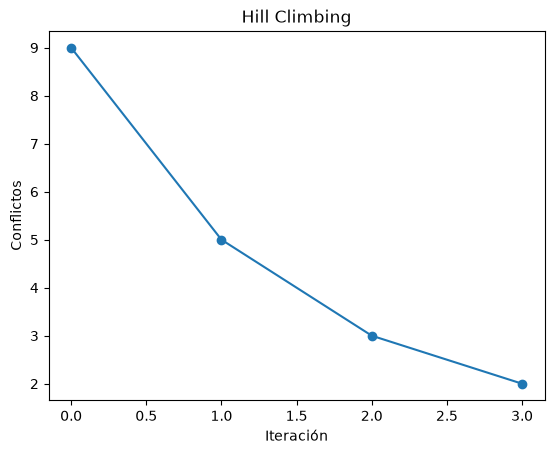

In [8]:
random.seed(RANDOM_STATE)
state_hc, costs_hc = hill_climbing(initial_state)
print("Estado final:", state_hc)
print("Costo final:", conflicts(state_hc))
print("Pasos:", len(costs_hc) - 1)

plt.plot(costs_hc, marker="o")
plt.xlabel("Iteración"); plt.ylabel("Conflictos")
plt.title("Hill Climbing")
plt.show()

## Actividad 4 — Simulated Annealing

Estamos minimizando. Define:

$$\Delta = C_{nuevo}-C_{actual}.$$

Si $\Delta\leq 0$, el movimiento no empeora. Si $\Delta>0$, se acepta con probabilidad:

$$P=\exp\left(-\frac{\Delta}{T}\right).$$

In [9]:
def acceptance_probability(current_cost, new_cost, temperature):
    """1 si el vecino mejora o iguala; exp(-delta/T) si empeora."""
    delta = new_cost - current_cost
    if delta <= 0:
        return 1.0
    return math.exp(-delta / temperature)


def simulated_annealing(initial_state, initial_temperature=10.0,
                        cooling_rate=0.995, min_temperature=1e-3,
                        max_steps=10_000):
    """Un vecino ALEATORIO por paso; se acepta segun acceptance_probability;
    la temperatura se enfria geometricamente. Devuelve final_state y history_costs."""
    state = list(initial_state)
    current_cost = conflicts(state)
    history = [current_cost]
    T = initial_temperature
    for _ in range(max_steps):
        if T < min_temperature or current_cost == 0:
            break
        cand = random.choice(get_neighbors(state))
        cand_cost = conflicts(cand)
        if random.random() < acceptance_probability(current_cost, cand_cost, T):
            state, current_cost = cand, cand_cost
        history.append(current_cost)
        T *= cooling_rate
    return state, history

Estado final: [4, 2, 0, 5, 7, 1, 3, 6]
Costo final: 0


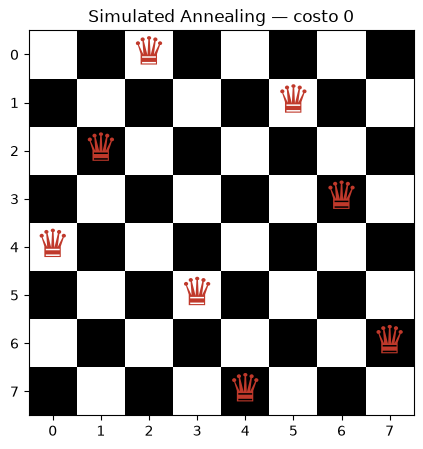

In [10]:
assert acceptance_probability(5, 4, 1.0) == 1.0
assert 0 < acceptance_probability(4, 5, 1.0) < 1

random.seed(RANDOM_STATE)
state_sa, costs_sa = simulated_annealing(initial_state)
print("Estado final:", state_sa)
print("Costo final:", conflicts(state_sa))
plot_board(state_sa, f"Simulated Annealing — costo {conflicts(state_sa)}")

## Actividad 5 — Comparación en varios reinicios

In [11]:
def random_state(n=N):
    return [random.randrange(n) for _ in range(n)]


def compare_algorithms(trials=30):
    algos = {
        "hill_climbing": lambda s: hill_climbing(s)[0],
        "simulated_annealing": lambda s: simulated_annealing(s)[0],
    }
    rows = []
    for name, fn in algos.items():
        finales = [conflicts(fn(random_state())) for _ in range(trials)]
        rows.append({
            "algoritmo": name,
            "tasa_exito (costo 0)": sum(1 for c in finales if c == 0) / trials,
            "costo_final_promedio": sum(finales) / trials,
        })
    return pd.DataFrame(rows)


random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
compare_algorithms(30)

,algoritmo,tasa_exito (costo 0),costo_final_promedio
0,hill_climbing,0.066667,1.266667
1,simulated_annealing,0.900000,0.100000


## Preguntas de análisis

1. ¿Por qué Hill Climbing puede detenerse con costo mayor que cero?
2. ¿Qué permite a Simulated Annealing escapar de mínimos locales?
3. Si el enfriamiento es demasiado rápido, ¿a cuál algoritmo empieza a parecerse?
4. ¿Qué ocurre si la temperatura permanece muy alta?

## Checklist

- [ ] Implementé costo y vecinos.
- [ ] Hill Climbing acepta solo mejoras.
- [ ] Simulated Annealing puede aceptar empeoramientos.
- [ ] Comparé ambos algoritmos en múltiples ejecuciones.